# Matplotlib Essentials for Plotting Signals
### CSE 219 — Everything you need to make clean, gradeable plots

Every assignment says *"plot with proper labels and legend"* — that phrasing
is graded literally. This notebook builds up, piece by piece, every plotting
feature you'll need: figure sizing, grids, line vs. stem (discrete) plots,
markers, legends, multiple subplots, axis limits (for ignoring out-of-range
values), and bar plots.

**Topics covered:**
1. Anatomy of a plot: `figure`, `plot`, `show`
2. `figsize` and why it matters for readability
3. Titles, axis labels, and `grid`
4. Continuous-time signals: `plt.plot`
5. Discrete-time signals: `plt.stem` (NOT `plt.plot`!)
6. Markers, linestyles, and colors
7. Legends — placement and multiple curves
8. Multiple subplots (side-by-side and stacked)
9. Setting axis limits (`xlim`/`ylim`) — for "ignore values beyond range"
10. Bar plots
11. Saving figures
12. A complete worked template you can copy for your submissions


## 1. Anatomy of a basic plot

The minimal recipe: create data → `plt.plot(x, y)` → `plt.show()`. In Jupyter,
`%matplotlib inline` (or the default in recent versions) renders the figure
directly below the cell.

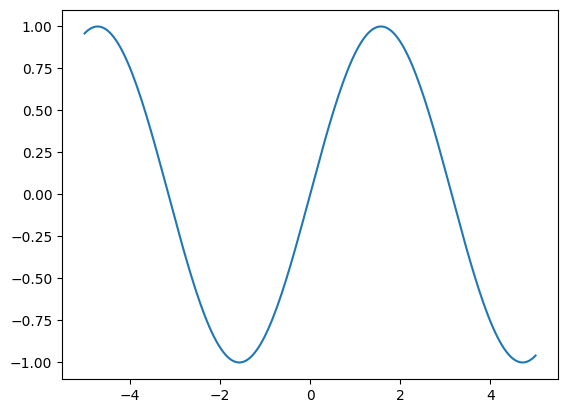

In [1]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(-5, 5, 200)
x = np.sin(t)

plt.plot(t, x)
plt.show()

This "works" but is not gradeable-quality: no title, no axis labels, no
grid, no legend, and the default size may be too small to read clearly. Every
section below fixes one of these.

## 2. `figsize` — controlling plot size

`plt.figure(figsize=(width, height))` sets the figure size **in inches**. Call
this *before* your plotting commands. A wider figure is often useful for
signals plotted over a long time axis so samples don't look squashed together.

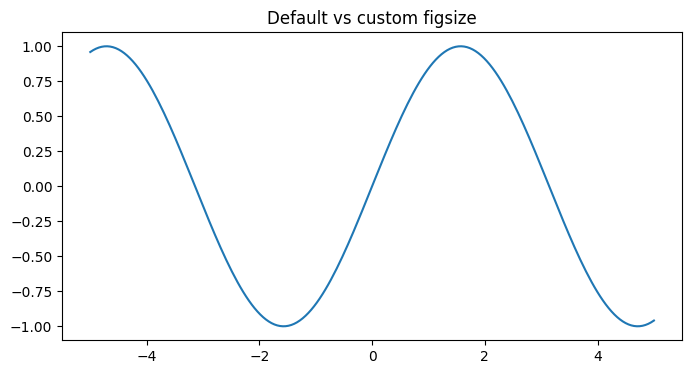

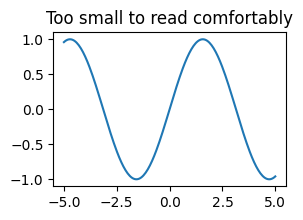

In [2]:
plt.figure(figsize=(8, 4))   # width=8in, height=4in -- a good default for signals
plt.plot(t, x)
plt.title("Default vs custom figsize")
plt.show()

# Compare: a small, cramped figure
plt.figure(figsize=(3, 2))
plt.plot(t, x)
plt.title("Too small to read comfortably")
plt.show()

## 3. Titles, axis labels, and grid

Every submitted plot should have: `plt.title(...)`, `plt.xlabel(...)`,
`plt.ylabel(...)`, and `plt.grid(True)`. Grids make it much easier to read
off specific values (zero-crossings, amplitude, etc.) — exactly what a grader
checks when verifying your signal transformations.

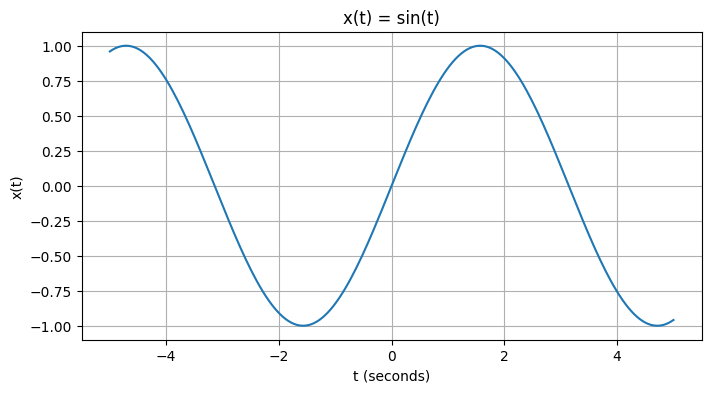

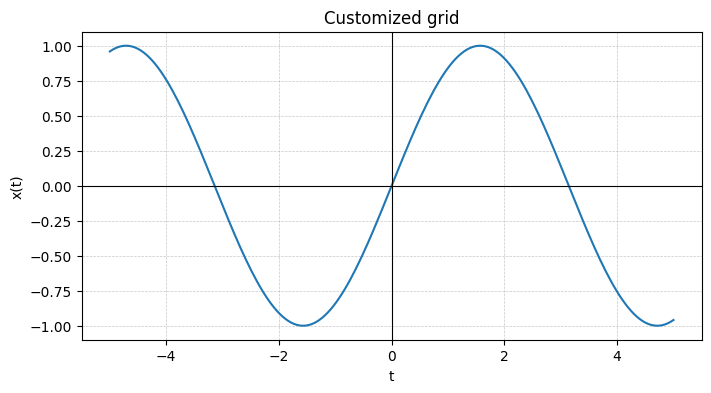

In [3]:
plt.figure(figsize=(8, 4))
plt.plot(t, x)
plt.title("x(t) = sin(t)")
plt.xlabel("t (seconds)")
plt.ylabel("x(t)")
plt.grid(True)                    # basic grid
plt.show()

# You can control which axis gets gridlines, and their style
plt.figure(figsize=(8, 4))
plt.plot(t, x)
plt.title("Customized grid")
plt.xlabel("t"); plt.ylabel("x(t)")
plt.grid(True, which='both', axis='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)   # emphasize the t-axis (y=0 line)
plt.axvline(0, color='black', linewidth=0.8)   # emphasize the x-axis (t=0 line)
plt.show()

`axhline`/`axvline` (horizontal/vertical reference lines at y=0 and t=0) are
especially useful for signals — they visually anchor even/odd symmetry and
make it obvious whether a transformation shifted the signal off-center.

## 4. Continuous-time signals: `plt.plot`

For a **continuous-time signal sampled densely** (like in Assignments 1 and 3),
`plt.plot` connecting the dots with a line is the correct representation —
it visually implies the signal exists for all `t`, even though you only
computed discrete samples.

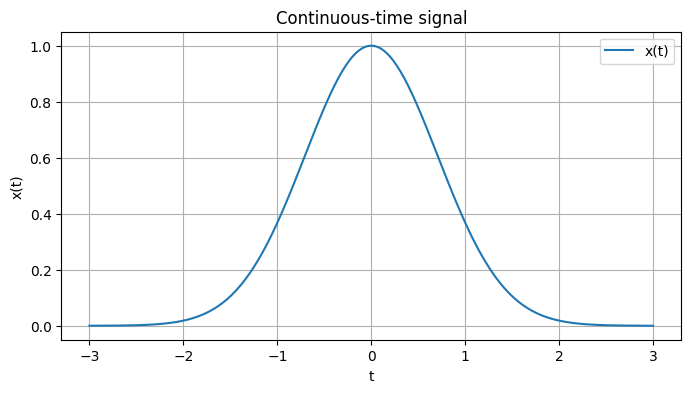

In [4]:
t = np.linspace(-3, 3, 300)
x = np.exp(-t**2)   # a Gaussian pulse, continuous-time style

plt.figure(figsize=(8, 4))
plt.plot(t, x, label="x(t)")
plt.title("Continuous-time signal")
plt.xlabel("t"); plt.ylabel("x(t)")
plt.grid(True)
plt.legend()
plt.show()

## 5. Discrete-time signals: `plt.stem` (NOT `plt.plot`!)

This is one of the most commonly missed grading points: **discrete-time
signals** (like the sinusoid `x[n]` in Assignment 2) should be plotted with
`plt.stem`, which draws individual vertical lines with markers at each sample —
correctly conveying that the signal is only defined at integer sample indices,
not "in between.

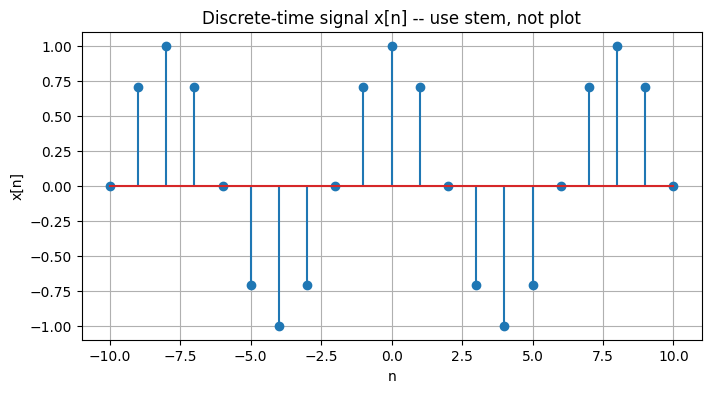

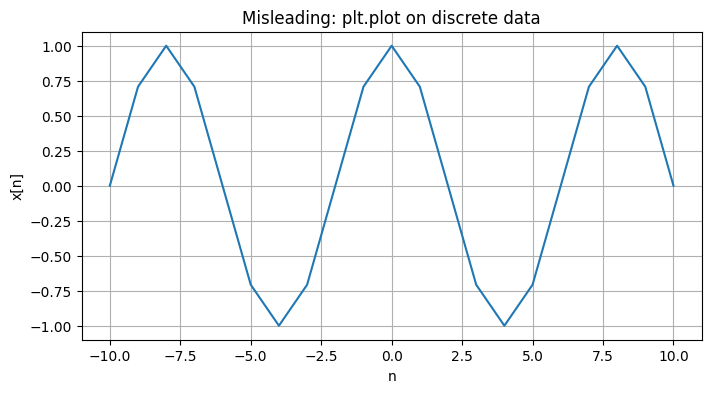

In [5]:
n = np.arange(-10, 11)
xn = np.cos(np.pi/4 * n)

plt.figure(figsize=(8, 4))
plt.stem(n, xn)               # correct choice for discrete-time signals
plt.title("Discrete-time signal x[n] -- use stem, not plot")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()

# For comparison, here's the WRONG way (implies continuity that isn't there):
plt.figure(figsize=(8, 4))
plt.plot(n, xn)
plt.title("Misleading: plt.plot on discrete data")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()

`plt.stem` also accepts styling arguments: `linefmt`, `markerfmt`, and
`basefmt` control the stem line color/style, the marker at the tip, and the
baseline, respectively.

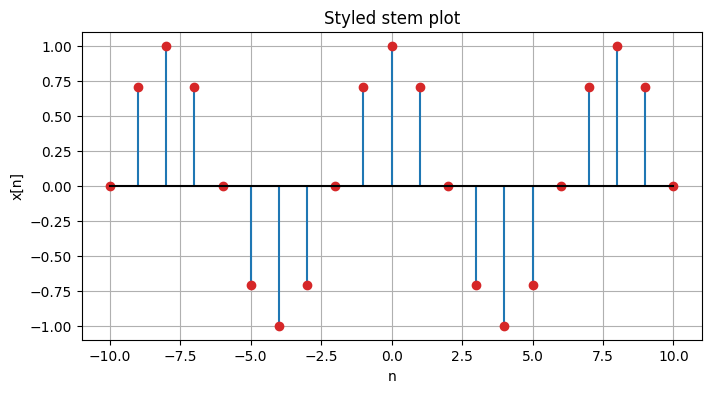

In [6]:
plt.figure(figsize=(8, 4))
plt.stem(n, xn, linefmt='C0-', markerfmt='C3o', basefmt='k-')
plt.title("Styled stem plot")
plt.xlabel("n"); plt.ylabel("x[n]")
plt.grid(True)
plt.show()

## 6. Markers, linestyles, and colors on `plt.plot`

For continuous-signal line plots, you can still add markers at sample points,
which is useful when you want to show *both* the sampled nature and a smooth
trend. The short-hand format string is `'[color][marker][linestyle]'`, e.g.
`'r--o'` = red, dashed line, circle markers.

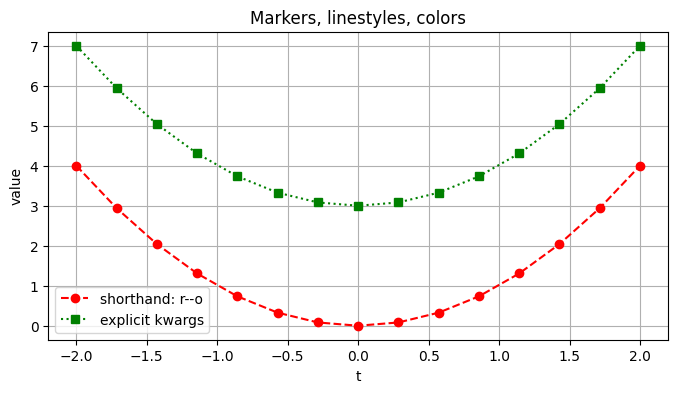

In [7]:
t = np.linspace(-2, 2, 15)
x = t**2

plt.figure(figsize=(8, 4))
plt.plot(t, x, 'r--o', label="shorthand: r--o")           # shorthand format string
plt.plot(t, x + 3, color='green', linestyle=':', marker='s', label="explicit kwargs")
plt.title("Markers, linestyles, colors")
plt.xlabel("t"); plt.ylabel("value")
plt.grid(True)
plt.legend()
plt.show()

**Common markers:** `'o'` circle, `'s'` square, `'^'` triangle, `'x'` cross,
`'*'` star, `'.'` point.
**Common linestyles:** `'-'` solid, `'--'` dashed, `':'` dotted, `'-.'` dash-dot.

## 7. Legends — placement and multiple curves

When you plot multiple signals on the same figure (e.g. `x(t)`, `x_e(t)`,
`x_o(t)` all overlaid — exactly Assignment 1's requirement), give each `plot`
call a `label=`, then call `plt.legend()` once.

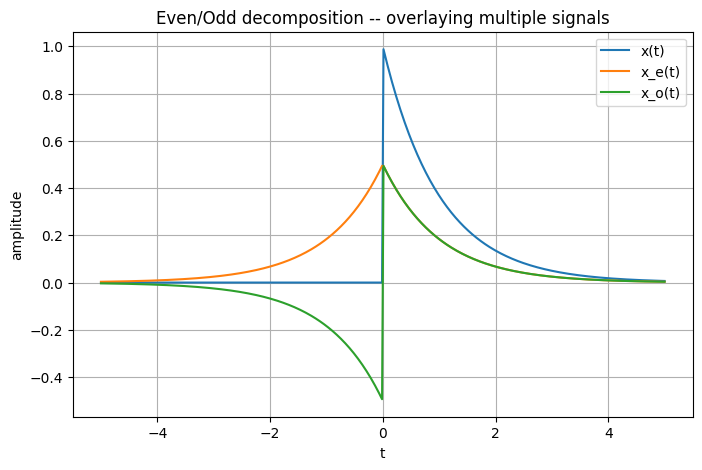

In [8]:
t = np.linspace(-5, 5, 400)
x = np.where(t >= 0, np.exp(-t), 0)   # a causal decaying signal, e.g. a "one-sided" x(t)
x_rev = x[::-1]                        # x(-t), NOT yet copied/handled correctly for axis,
                                        # shown here purely to illustrate the PLOTTING pattern
x_even = (x + x_rev) / 2
x_odd  = (x - x_rev) / 2

plt.figure(figsize=(8, 5))
plt.plot(t, x,      label="x(t)")
plt.plot(t, x_even, label="x_e(t)")
plt.plot(t, x_odd,  label="x_o(t)")
plt.title("Even/Odd decomposition -- overlaying multiple signals")
plt.xlabel("t"); plt.ylabel("amplitude")
plt.grid(True)
plt.legend()                 # matplotlib auto-picks a sensible default location
plt.show()

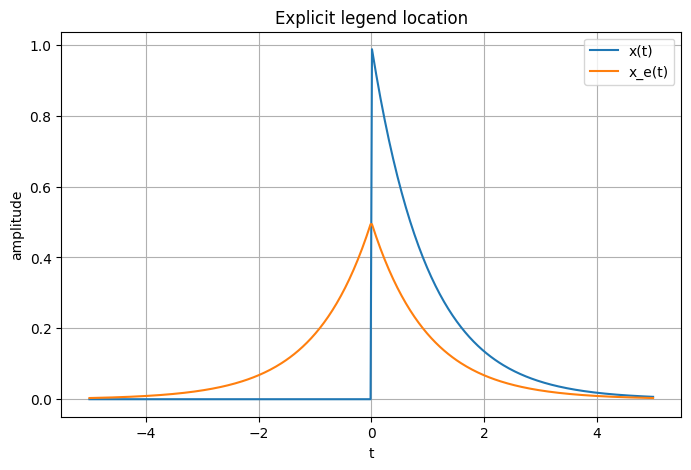

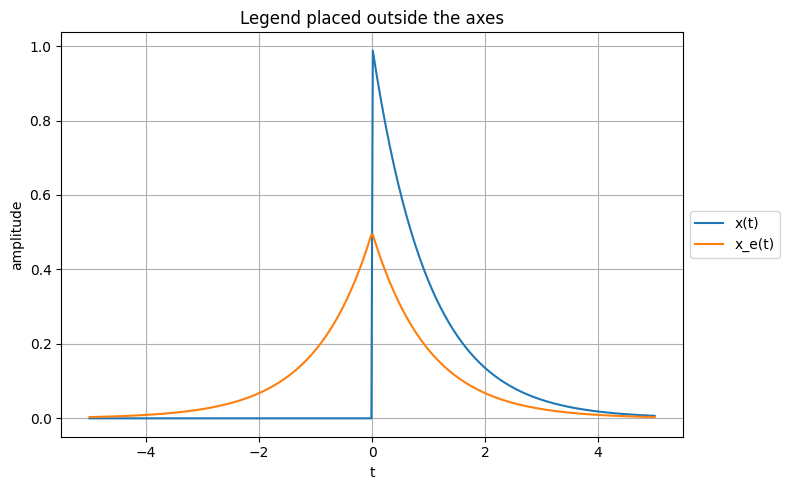

In [9]:
# Controlling legend placement explicitly
plt.figure(figsize=(8, 5))
plt.plot(t, x, label="x(t)")
plt.plot(t, x_even, label="x_e(t)")
plt.legend(loc='upper right')          # options: 'upper left', 'lower right', 'best', etc.
plt.title("Explicit legend location")
plt.xlabel("t"); plt.ylabel("amplitude")
plt.grid(True)
plt.show()

# Legend outside the plot area (handy when curves are busy near a corner)
plt.figure(figsize=(8, 5))
plt.plot(t, x, label="x(t)")
plt.plot(t, x_even, label="x_e(t)")
plt.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.title("Legend placed outside the axes")
plt.xlabel("t"); plt.ylabel("amplitude")
plt.grid(True)
plt.tight_layout()          # prevents the outside legend from getting clipped
plt.show()

## 8. Multiple subplots

Assignments often ask for **separate** plots (e.g. Assignment 1: one figure
with `x(t)`, `x_e(t)`, `x_o(t)` together, *and* a separate figure of `x(t)` vs
`x(-t)`). `plt.subplots(rows, cols)` is the cleanest way to arrange multiple
axes, whether in one figure (stacked/side-by-side) or as fully separate figures.

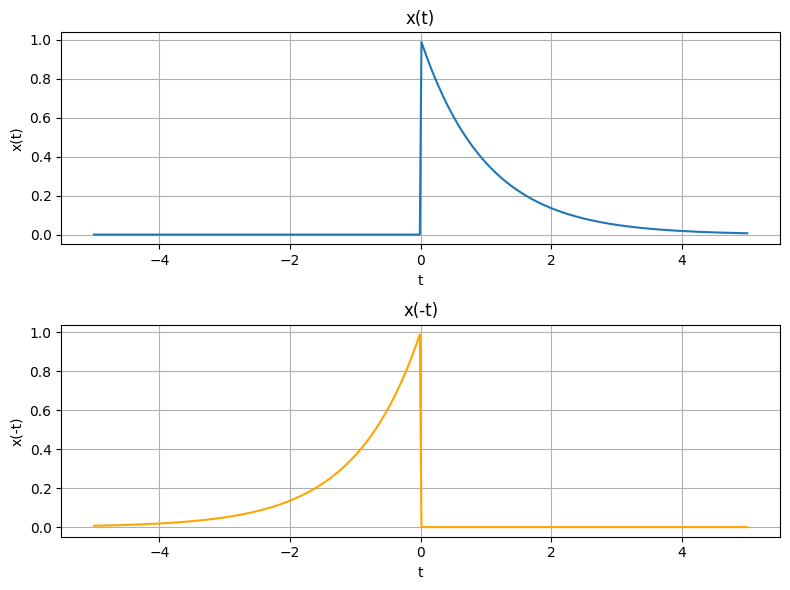

In [10]:
# --- Stacked subplots in ONE figure (e.g. comparing x(t) and x(-t)) ---
fig, axes = plt.subplots(2, 1, figsize=(8, 6))   # 2 rows, 1 column

axes[0].plot(t, x)
axes[0].set_title("x(t)")
axes[0].set_xlabel("t"); axes[0].set_ylabel("x(t)")
axes[0].grid(True)

axes[1].plot(t, x_rev, color='orange')
axes[1].set_title("x(-t)")
axes[1].set_xlabel("t"); axes[1].set_ylabel("x(-t)")
axes[1].grid(True)

plt.tight_layout()     # avoids overlapping titles/labels between subplots
plt.show()

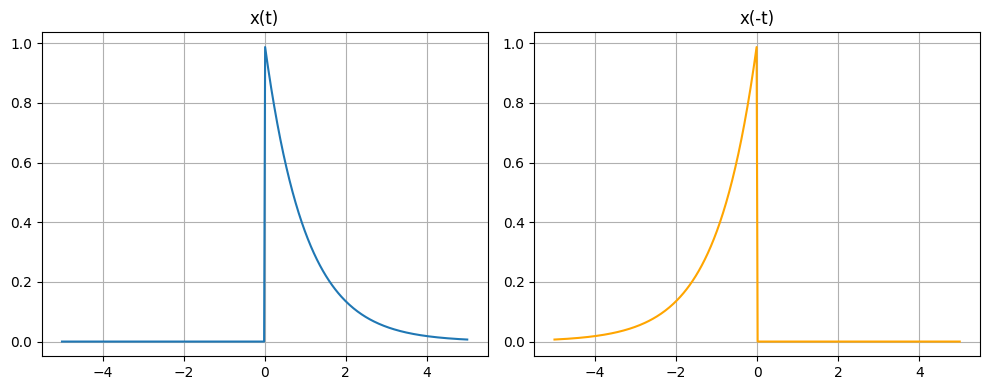

In [11]:
# --- Side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(t, x)
axes[0].set_title("x(t)"); axes[0].grid(True)

axes[1].plot(t, x_rev, color='orange')
axes[1].set_title("x(-t)"); axes[1].grid(True)

plt.tight_layout()
plt.show()

**Note the API difference:** with `plt.plot(...)` you call `plt.title()`,
`plt.xlabel()` directly. With subplot **axes objects** (`axes[0]`, `axes[1]`),
you call `.set_title()`, `.set_xlabel()`, `.set_ylabel()` instead (the `ax.`
methods are prefixed with `set_`). Mixing these up is a common source of
`AttributeError`s.

## 9. Axis limits — implementing "ignore values beyond range"

Assignment 3 explicitly says: *"Ignore the values that go beyond the specified
time range."* There are two complementary tools:
- **`plt.xlim(low, high)` / `plt.ylim(low, high)`**: crops the *view*, without
  touching your data — quick, but data outside the range is still technically
  in your arrays.
- **Filtering the data itself** (with a boolean mask, see the NumPy notebook)
  before plotting: the more correct approach when the assignment asks you to
  actually exclude those samples from computation, not just hide them visually.

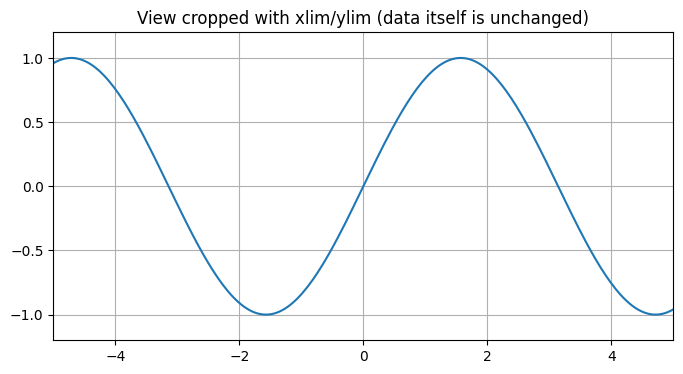

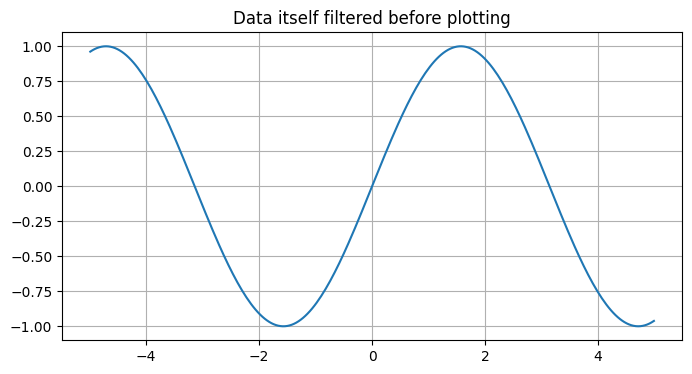

In [12]:
t = np.linspace(-10, 10, 500)
y = np.sin(t)

# Approach A: just crop the view (data still includes points outside [-5, 5])
plt.figure(figsize=(8, 4))
plt.plot(t, y)
plt.xlim(-5, 5)
plt.ylim(-1.2, 1.2)
plt.title("View cropped with xlim/ylim (data itself is unchanged)")
plt.grid(True)
plt.show()

# Approach B: actually filter the data first (preferred when the assignment
# asks you to exclude out-of-range SAMPLES, not just the visual window)
mask = (t >= -5) & (t <= 5)
plt.figure(figsize=(8, 4))
plt.plot(t[mask], y[mask])
plt.title("Data itself filtered before plotting")
plt.grid(True)
plt.show()

## 10. Bar plots

Less common for continuous signals, but useful for things like comparing
**energy/power values** across different signals or transformations
side by side, or visualizing a small set of discrete sample values.

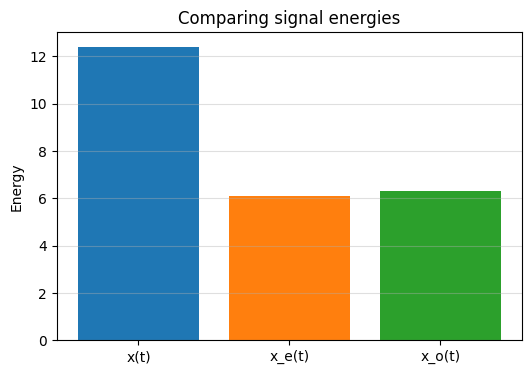

In [13]:
labels = ['x(t)', 'x_e(t)', 'x_o(t)']
energies = [12.4, 6.1, 6.3]   # example placeholder values

plt.figure(figsize=(6, 4))
plt.bar(labels, energies, color=['C0', 'C1', 'C2'])
plt.title("Comparing signal energies")
plt.ylabel("Energy")
plt.grid(True, axis='y', alpha=0.4)   # horizontal gridlines only, common for bar charts
plt.show()

## 11. Saving figures

`plt.savefig(filename, dpi=..., bbox_inches='tight')` — call this **before**
`plt.show()`, since some backends clear the figure after showing it. Useful if
you need to embed the plot in a report or submission separately from the
notebook.

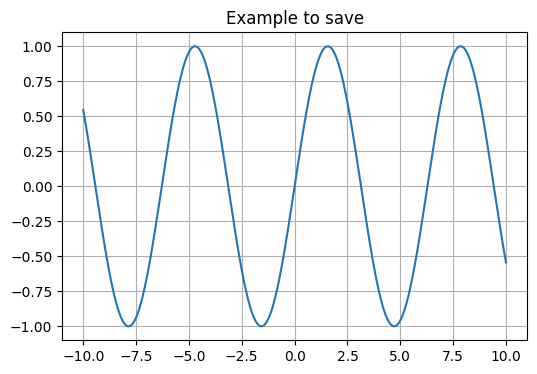

Saved.


In [14]:
plt.figure(figsize=(6, 4))
plt.plot(t, y)
plt.title("Example to save")
plt.grid(True)
plt.savefig('/home/claude/example_signal_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## 12. A complete worked template

Copy-paste starting point that hits every checklist item graders look for:
figsize, title, axis labels, grid, legend, and correct plot type for the
signal's nature (continuous → `plot`, discrete → `stem`).

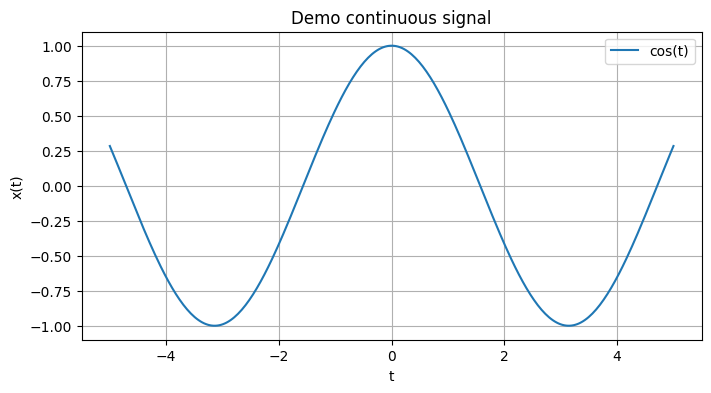

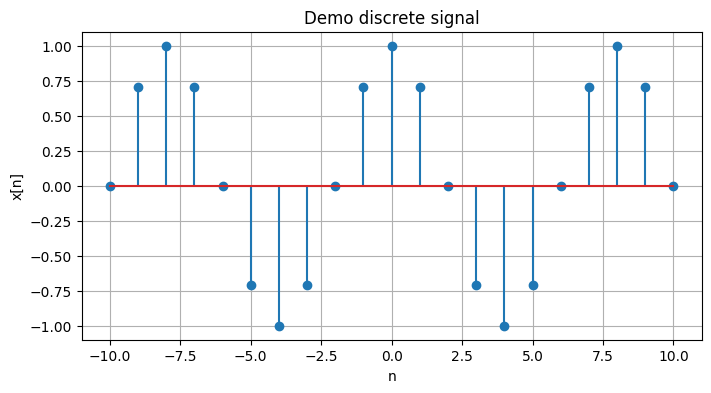

In [15]:
def plot_continuous_signal(t, x, title="", xlabel="t", ylabel="x(t)", label=None):
    plt.figure(figsize=(8, 4))
    plt.plot(t, x, label=label)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    if label:
        plt.legend()
    plt.show()

def plot_discrete_signal(n, x, title="", xlabel="n", ylabel="x[n]"):
    plt.figure(figsize=(8, 4))
    plt.stem(n, x)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

# Demo usage
t_demo = np.linspace(-5, 5, 300)
plot_continuous_signal(t_demo, np.cos(t_demo), title="Demo continuous signal", label="cos(t)")

n_demo = np.arange(-10, 11)
plot_discrete_signal(n_demo, np.cos(np.pi/4*n_demo), title="Demo discrete signal")

## Summary checklist for every plot you submit

- [ ] `plt.figure(figsize=(...))` set before plotting
- [ ] `plt.title(...)` describing exactly what's shown
- [ ] `plt.xlabel(...)` and `plt.ylabel(...)` with units/variable names
- [ ] `plt.grid(True)`
- [ ] Correct plot type: `plt.plot` for continuous-time, `plt.stem` for discrete-time
- [ ] `label=...` on every curve + one `plt.legend()` call when multiple signals share a figure
- [ ] `plt.tight_layout()` when using subplots
- [ ] Axis range appropriately limited/filtered when the assignment asks you to ignore out-of-range values
